<a href="https://colab.research.google.com/github/Suraj-Patil1601/HR-Attrition-Analysis/blob/main/EDA_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## HR Attrition Analysis – Understanding Factors Influencing Employee Turnover

# Problem Statement

Employee attrition (employee turnover) is a major challenge for organizations as it leads to increased recruitment costs, productivity loss, and reduced employee morale.

The objective of this project is to analyze HR data to identify key factors contributing to employee attrition and provide actionable insights to reduce turnover.

# Project Objectives

* Understand dataset structure and variables

* Perform data cleaning and wrangling

* Conduct univariate, bivariate, and multivariate analysis

* Identify key drivers of attrition

* Generate business insights

* Provide recommendations to HR management

#Tools & Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as p

#Dataset Loading

In [ ]:
data= pd.read_csv("Employee-Attrition.csv")
data


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [ ]:
data.shape

(1470, 35)

In [ ]:
data.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


| Column Name      | Description                            | Data Type   |
| ---------------- | -------------------------------------- | ----------- |
| Age              | Employee age                           | Numerical   |
| Attrition        | Whether employee left company (Yes/No) | Categorical |
| BusinessTravel   | Travel frequency                       | Categorical |
| DailyRate        | Daily salary rate                      | Numerical   |
| Department       | Employee department                    | Categorical |
| DistanceFromHome | Distance between home & office         | Numerical   |
| Education        | Education level                        | Categorical |
| Gender           | Male/Female                            | Categorical |
| JobRole          | Employee job role                      | Categorical |
| MonthlyIncome    | Monthly salary                         | Numerical   |
| YearsAtCompany   | Total years worked                     | Numerical   |


#Preliminary Data Exploration

In [ ]:
data.shape

(1470, 35)

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
data.describe()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
data.isnull().sum()


,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
data.nunique

<bound method DataFrame.nunique of       Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EmployeeCount  \
0                    1          2  Life Sciences              1   
1                    8          1  Life Sciences              1   
2                    2          2          Other              1   
3                    3          4  Life Sciences              1   
4                    2          1        Medical              1   
...                ...        ...            ...            ...   
1465                23          2        Medical              1   
1466                 6          1        Medical              1   
1467                 4          3  Life Sciences              1   
1468                 2          3        Medical              1   
1469                 8          3        Medical              1   

      EmployeeNumber  ...  RelationshipSatisfaction StandardHours  \
0                  1  ...                         1            80   
1                  2  ...                         4            80   
2                  4  ...                         2            80   
3                  5  ...                         3            80   
4                  7  ...                         4            80   
...              ...  ...                       ...           ...   
1465            2061  ...                         3            80   
1466            2062  ...                         1            80   
1467            2064  ...                         2            80   
1468            2065  ...                         4            80   
1469            2068  ...                         1            80   

      StockOptionLevel  TotalWorkingYears  TrainingTimesLastYear  \
0                    0                  8                      0   
1                    1                 10                      3   
2                    0                  7                      3   
3                    0                  8                      3   
4                    1                  6                      3   
...                ...                ...                    ...   
1465                 1                 17                      3   
1466                 1                  9                      5   
1467                 1                  6                      0   
1468                 0                 17                      3   
1469                 0                  6                      3   

     WorkLifeBalance  YearsAtCompany YearsInCurrentRole  \
0                  1               6                  4   
1                  3              10                  7   
2                  3               0                  0   
3                  3               8                  7   
4                  3               2                  2   
...              ...             ...                ...   
1465               3               5                  2   
1466               3               7                  7   
1467               3               6                  2   

In [ ]:
data['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


# Data Wrangling
1. Column Handling

In [ ]:
data.drop(['EmployeeCount','StandardHours','Over18','EmployeeNumber'], axis=1, inplace=True)

In [ ]:
data.rename(columns={'MonthlyIncome':'Monthly_Income'}, inplace=True)

2. Feature Creation

In [ ]:
data['Income_Per_YearAtCompany'] = data['Monthly_Income'] / (data['YearsAtCompany'] + 1)

3. Data Type Conversion

In [ ]:
data['Attrition'] = data['Attrition'].astype('category')
data['Department'] = data['Department'].astype('category')

# Data Cleaning


In [ ]:
#Duplicate Handling
data.duplicated().sum()
data.drop_duplicates(inplace=True)

In [ ]:
#missing values
data.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


In [ ]:
#if any missing
data['Monthly_Income'].fillna(data['Monthly_Income'].median(), inplace=True)

/tmp/ipython-input-2198838894.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Monthly_Income'].fillna(data['Monthly_Income'].median(), inplace=True)


# Data Visualization

#1 Univariate Analysis

1.1 Attrition Distribution

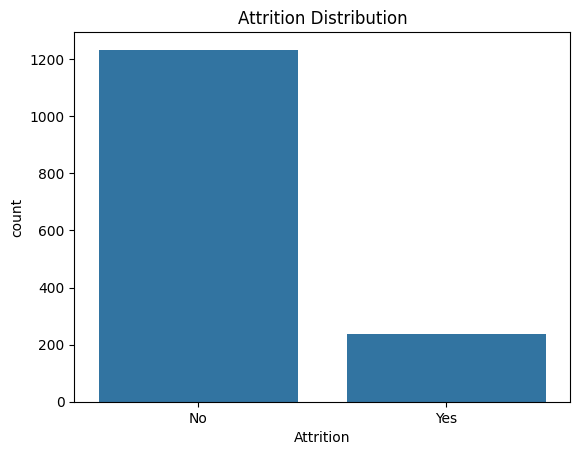

In [ ]:
sns.countplot(x='Attrition', data=data)
plt.title("Attrition Distribution")
plt.show()



Key Insights

. Majority of employees are retained, but a noticeable portion has left.

. Attrition exists at a meaningful level and cannot be ignored.

. Indicates the need to identify high-risk employee segments.

1.2 Age Distribution

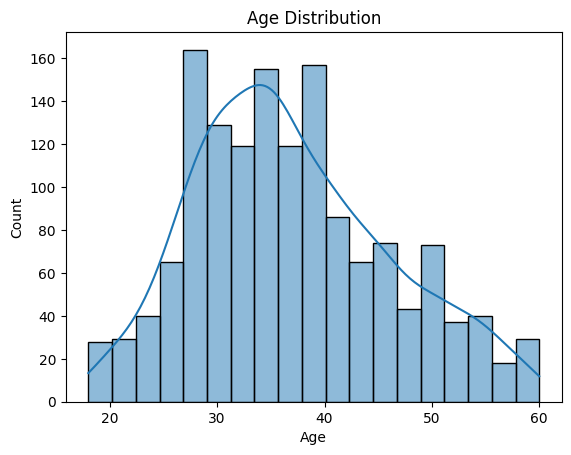

In [ ]:
sns.histplot(data['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

Key Insights

. Workforce is predominantly between 25–40 years.

. Organization has a relatively young employee base.

. Younger workforce may lead to higher job mobility.

1.3 Monthly Income Distribution

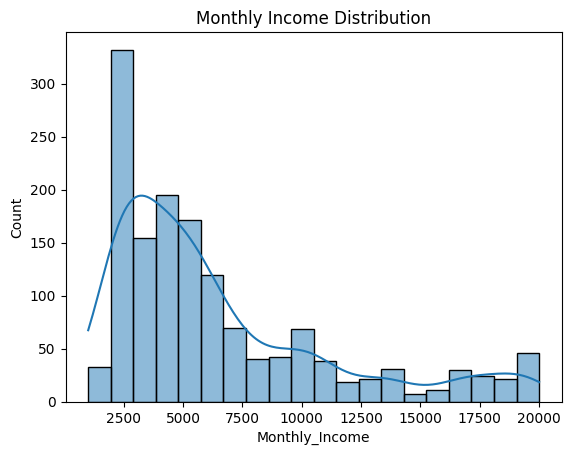

In [ ]:
sns.histplot(data['Monthly_Income'], kde=True)
plt.title("Monthly Income Distribution")
plt.show()

Key Insights

. Income distribution is right-skewed.

. Majority employees fall in lower-to-mid salary range.

. Smaller group earns significantly higher salaries, indicating pay hierarchy.

1.4 Department Distribution

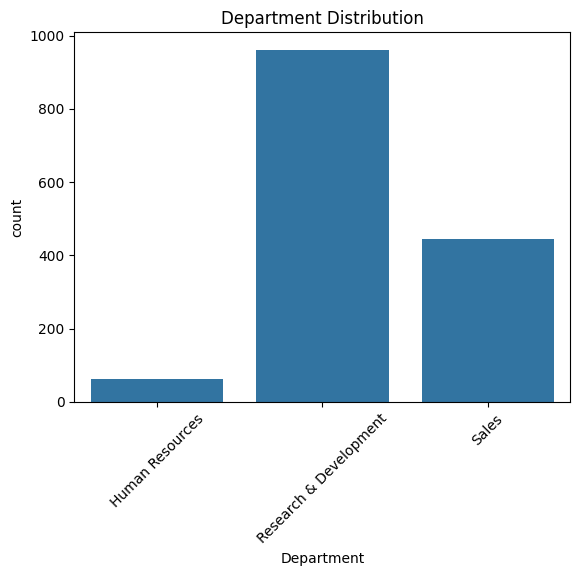

In [ ]:
sns.countplot(x='Department', data=data)
plt.xticks(rotation=45)
plt.title("Department Distribution")
plt.show()

Key Insights

. Sales department has highest employee count.

. Workforce distribution is not equal across departments.

. Department size must be considered when analyzing attrition counts.

1.5 Job Role Distribution

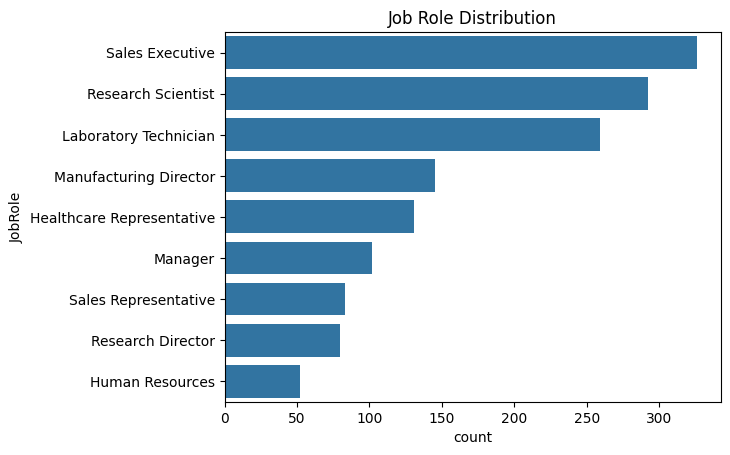

In [ ]:
sns.countplot(y='JobRole', data=data)
plt.title("Job Role Distribution")
plt.show()

Key Insights

. Sales Executive and Research Scientist are dominant roles.

. High-frequency roles may contribute more to overall attrition numbers.

. Role concentration helps contextualize turnover later..

1.6 Years at Company

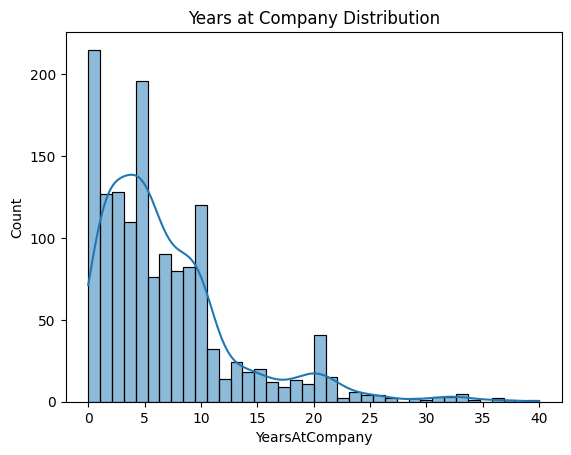

In [ ]:
sns.histplot(data['YearsAtCompany'], kde=True)
plt.title("Years at Company Distribution")
plt.show()

Key Insights

. Most employees have less than 5 years tenure.

. Organization has many early-career employees.

. Short tenure distribution may influence attrition rates.

1.7 Overtime Distribution

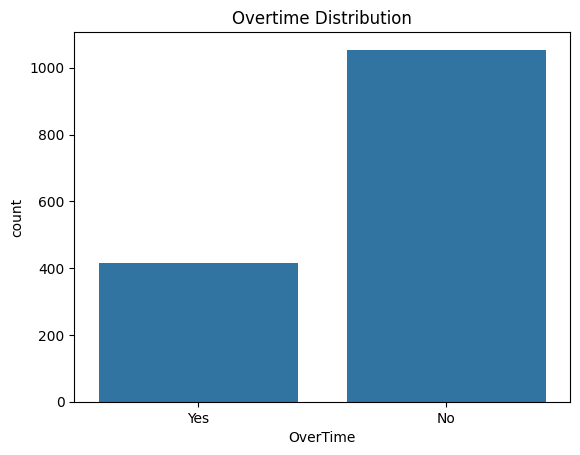

In [ ]:
sns.countplot(x='OverTime', data=data)
plt.title("Overtime Distribution")
plt.show()

Key Insights

. Significant number of employees work overtime.

. Indicates potential workload pressure.

. Overtime becomes an important factor in attrition analysis.

1.8 Job Satisfaction Level

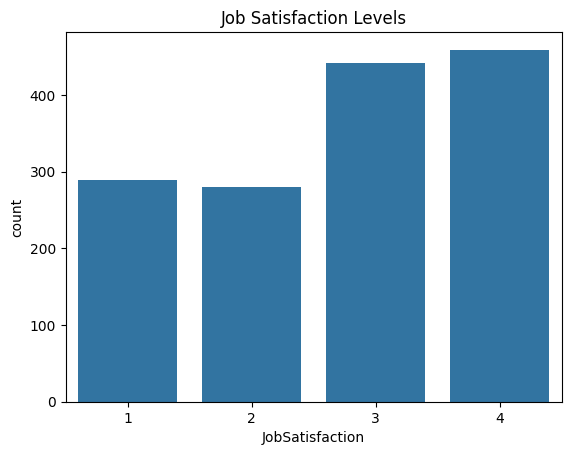

In [ ]:
sns.countplot(x='JobSatisfaction', data=data)
plt.title("Job Satisfaction Levels")
plt.show()

Key Insights

. Satisfaction levels vary across employees.

. Presence of low satisfaction scores indicates engagement concerns.

. Job satisfaction may act as a psychological retention factor.

#2 BIVARIATE ANALYSIS

2.1 Attrition vs Gender

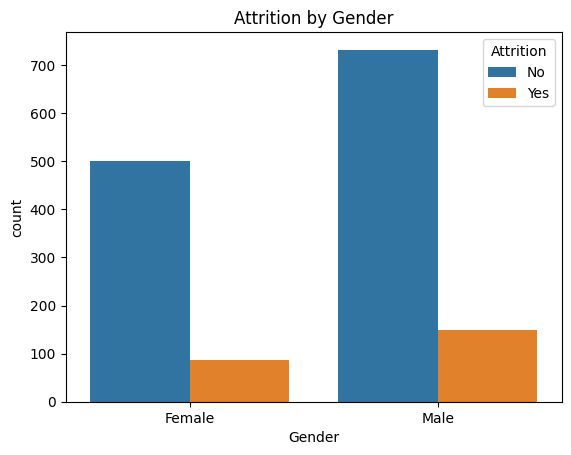

In [ ]:
sns.countplot(x='Gender', hue='Attrition', data=data)
plt.title("Attrition by Gender")
plt.show()

Key Insights

. Attrition is relatively balanced across genders.

. Gender is not a primary driver of turnover.

. Turnover is more job-related than demographic-based.

2.2 Attrition vs Department

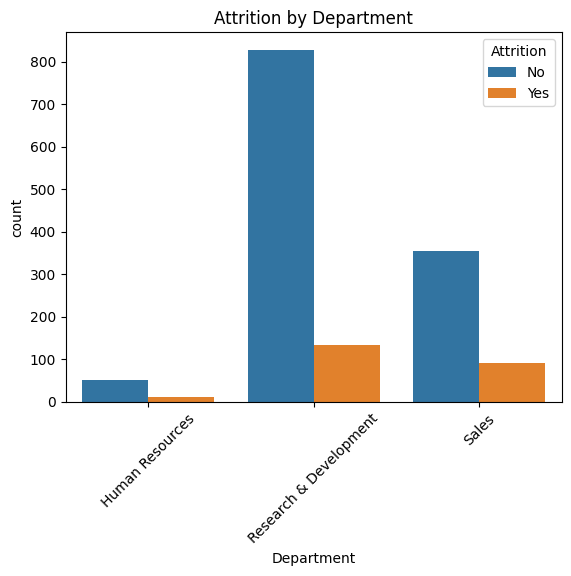

In [ ]:
sns.countplot(x='Department', hue='Attrition', data=data)
plt.xticks(rotation=45)
plt.title("Attrition by Department")
plt.show()

Key Insights

. Sales department shows higher attrition proportion.

. Departmental workload and targets may influence exits.

. Department-specific strategies are required.

2.3 Attrition vs Overtime

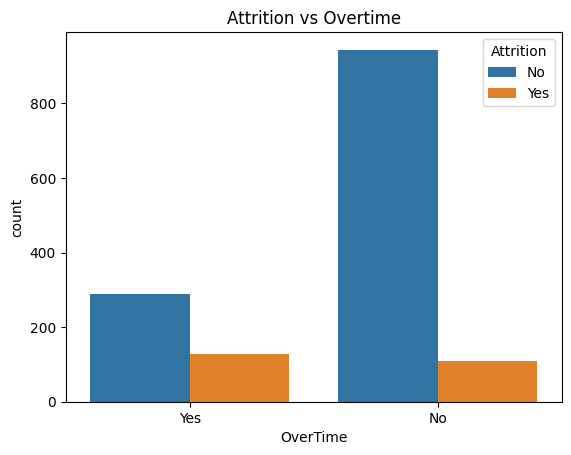

In [ ]:
sns.countplot(x='OverTime', hue='Attrition', data=data)
plt.title("Attrition vs Overtime")
plt.show()

Key Insights

. Employees working overtime have significantly higher attrition.

. Overtime is one of the strongest attrition predictors.

. Burnout and workload pressure impact
retention.

2.4 Monthly Income vs Attrition

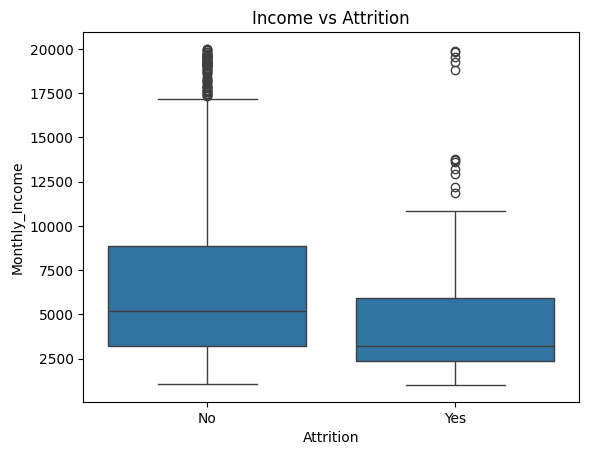

In [ ]:
sns.boxplot(x='Attrition', y='Monthly_Income', data=data)
plt.title("Income vs Attrition")
plt.show()

Key Insights

. Employees who left have lower median income.

. Compensation dissatisfaction may drive exits.

. Entry-level employees are more vulnerable.

2.5 YearsAtCompany vs Attrition

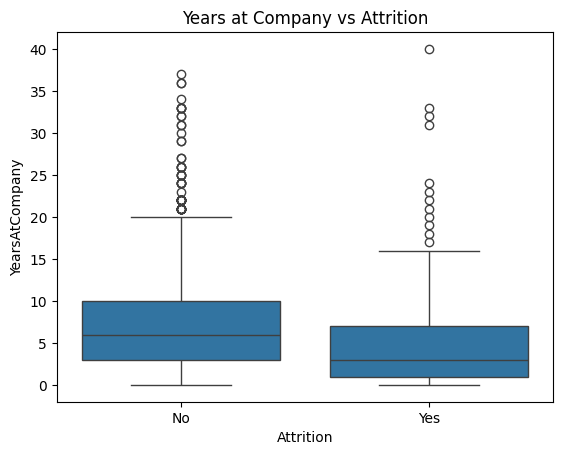

In [ ]:
sns.boxplot(x='Attrition', y='YearsAtCompany', data=data)
plt.title("Years at Company vs Attrition")
plt.show()

Key Insights

. Highest attrition seen in employees with low tenure.

. Early-career retention is a challenge.

. Employees may leave before long-term benefits materialize.

2.6 Job Satisfaction vs Attrition

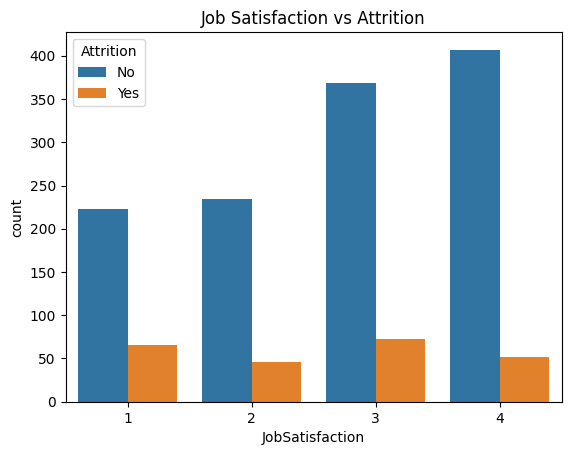

In [ ]:
sns.countplot(x='JobSatisfaction', hue='Attrition', data=data)
plt.title("Job Satisfaction vs Attrition")
plt.show()

Key Insights

. Lower satisfaction levels strongly correlate with attrition.

. Employee engagement directly impacts retention.

. Satisfaction is a major psychological driver.

2.7 Distance From Home vs Attrition

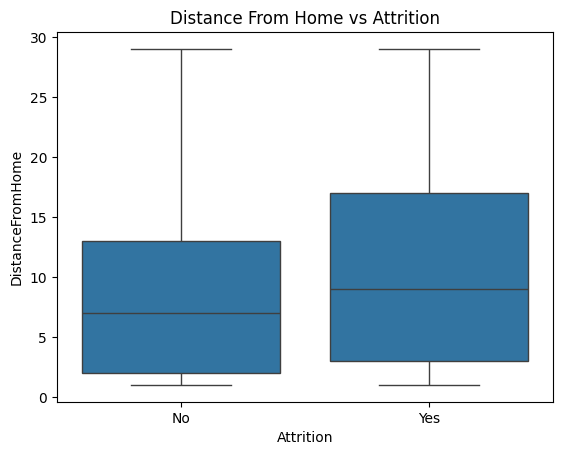

In [ ]:
sns.boxplot(x='Attrition', y='DistanceFromHome', data=data)
plt.title("Distance From Home vs Attrition")
plt.show()

Key Insights

. Slightly higher attrition among employees living farther.

. Commute distance may contribute to dissatisfaction.

. Flexible work policies may help reduce this risk.

2.8 Job Role vs Attrition

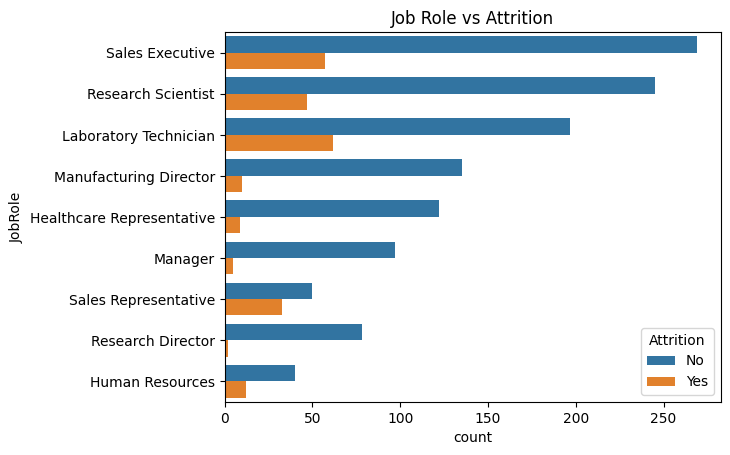

In [ ]:
sns.countplot(y='JobRole', hue='Attrition', data=data)
plt.title("Job Role vs Attrition")
plt.show()

Key Insights

. Certain job roles show higher attrition levels.

. Sales-related roles appear more vulnerable.

. Role-based workload and expectations influence turnover.

#3 MULTIVARIATE ANALYSIS

3.1 Correlation Heatmap

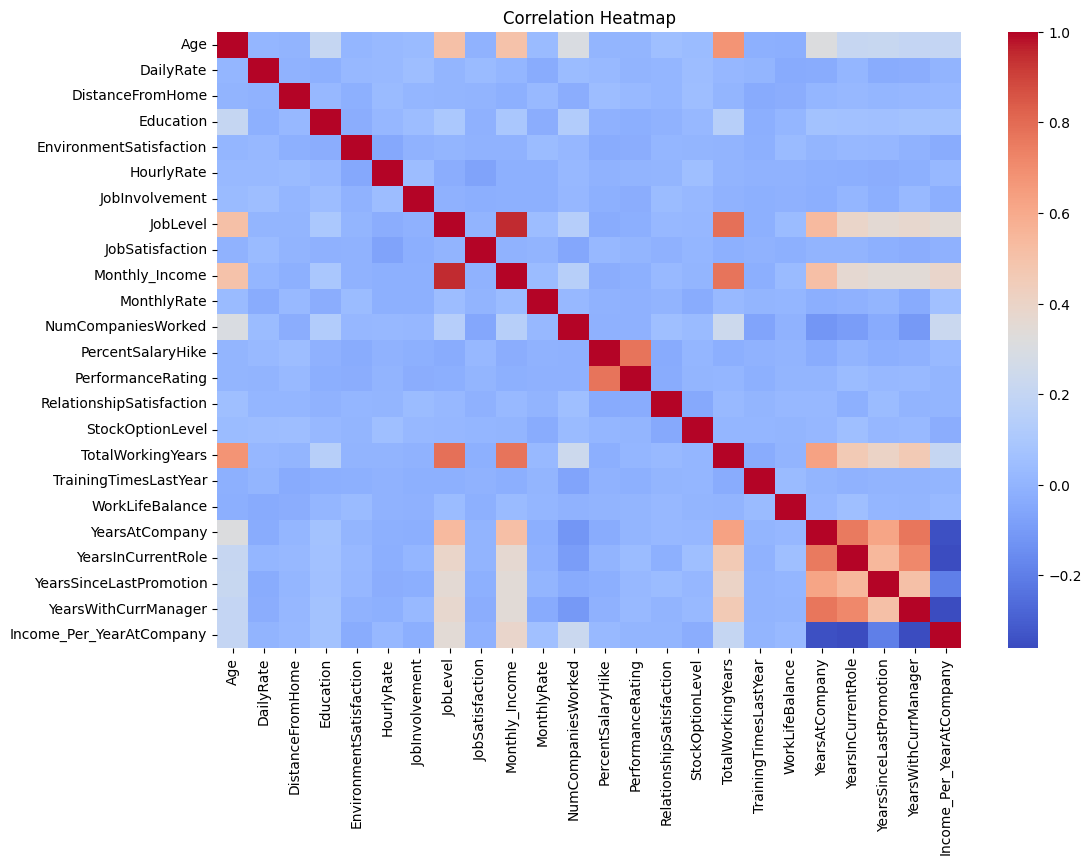

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Key Insights

. Strong correlation between MonthlyIncome and JobLevel.

. Age strongly correlates with TotalWorkingYears.

. Compensation growth structure is hierarchical.

. No single numeric variable perfectly predicts attrition.

3.2 Pairplot

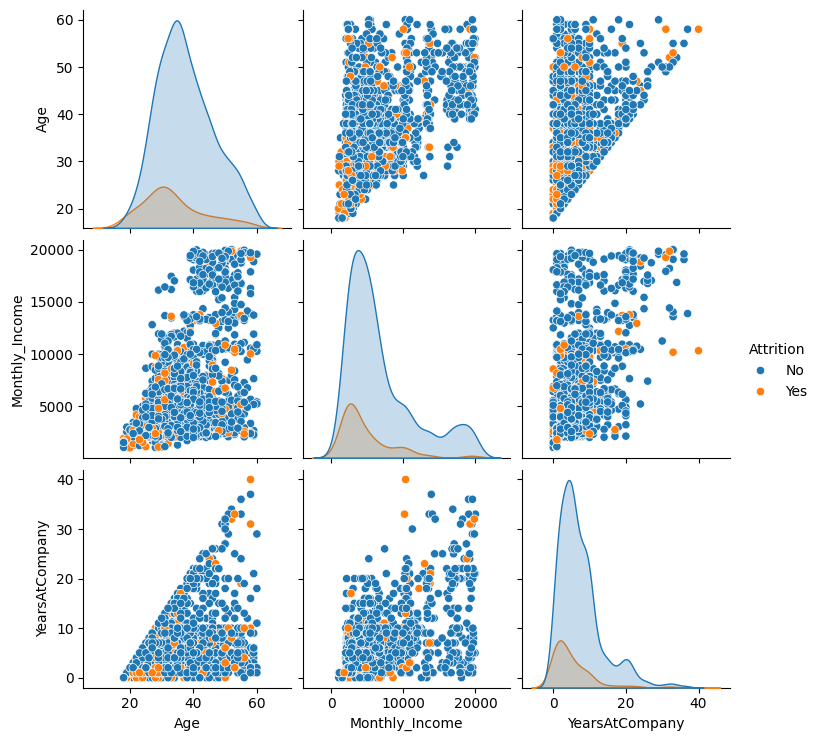

In [ ]:
sns.pairplot(data[['Age','Monthly_Income','YearsAtCompany','Attrition']],
             hue='Attrition')
plt.show()

Key Insights

. Attrition clusters around lower income and lower tenure.

. Employees with fewer years and lower pay are high-risk.

. Attrition is multi-variable driven.

3.3 Age vs Monthly Income vs Attrition

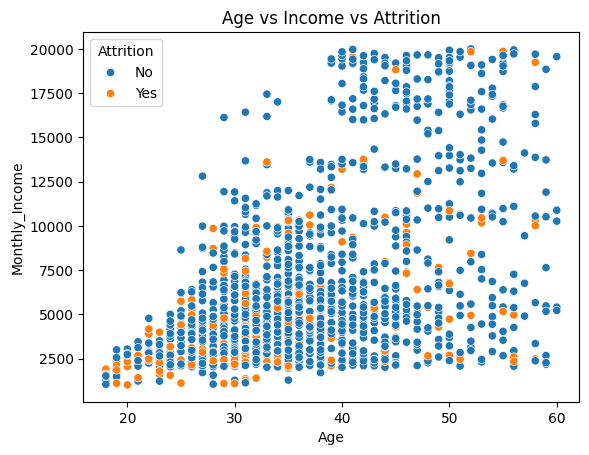

In [ ]:
sns.scatterplot(x='Age', y='Monthly_Income',
                hue='Attrition', data=data)
plt.title("Age vs Income vs Attrition")
plt.show()

Key Insights

. Younger employees with lower income show higher attrition density.

. Income growth trajectory may not be fast enough for early employees.

. Early salary adjustments could improve retention.

3.4 Overtime + Job Satisfaction + Attrition

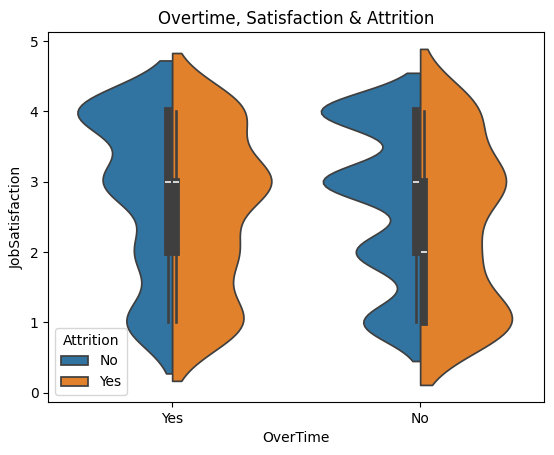

In [ ]:
sns.violinplot(x='OverTime', y='JobSatisfaction',
               hue='Attrition', data=data, split=True)
plt.title("Overtime, Satisfaction & Attrition")
plt.show()

Key Insights

. Employees working overtime with low satisfaction have highest attrition.

. Burnout combined with dissatisfaction increases exit probability.

. Workload and engagement together amplify attrition risk.

#Final Conclusion

The Exploratory Data Analysis of the HR Attrition dataset reveals that employee turnover is primarily influenced by workload pressure, compensation levels, job satisfaction, and tenure within the organization.

Attrition is significantly higher among employees who:

. Work overtime

. Earn lower monthly income

. Have less than 3–5 years of experience in the company

. Report lower job satisfaction levels

. Demographic factors such as gender show minimal impact on attrition, indicating that turnover is more strongly driven by organizational and job-related factors rather than personal characteristics.

. The analysis also highlights that early-career employees form the most vulnerable group, suggesting that the organization faces challenges in retaining talent during the initial years of employment.

. Overall, attrition is multi-factor driven, with burnout, compensation dissatisfaction, and engagement issues acting as the primary contributors. Addressing these structural concerns can significantly reduce employee turnover and improve workforce stability.

 **Strong Recommendations**

Based on the analysis, the following recommendations are proposed:

1. Reduce Excessive Overtime

* Monitor workload distribution across departments.

* Implement policies to prevent burnout.

* Encourage work-life balance initiatives.

2. Improve Compensation Structure

* Review salary competitiveness for entry-level employees.

* Introduce performance-based incentives.

* Ensure timely salary progression in early career stages.

3. Strengthen Early-Career Retention

* Enhance onboarding and training programs.

* Conduct regular check-ins during first 2–3 years.

* Provide clear career growth pathways.

4. Increase Employee Engagement

* Conduct regular job satisfaction surveys.

* Address dissatisfaction drivers proactively.

* Recognize and reward employee contributions.

5. Department-Specific Retention Strategy

* Focus on high-attrition departments such as Sales.

* Introduce stress management programs.

* Offer flexible targets and realistic performance expectations.

6. Promote Work-Life Balance

* Encourage flexible working hours where possible.

* Consider hybrid or remote options for employees with long commute distances.

7. Develop Predictive Monitoring System

* Identify high-risk employees using factors like overtime, low satisfaction, and low tenure.

* Take preventive action before employees decide to leave.

#Final Strategic Recommendation Summary

To effectively reduce attrition, the organization should shift from reactive hiring strategies to proactive retention management by improving compensation growth, reducing burnout, strengthening early engagement, and fostering a supportive work culture.
